<a href="https://colab.research.google.com/github/diabateyoussouf/saas-churn-prediction-shap/blob/main/WA_Fn_UseC__Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Analyse exploirateur-EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [6]:
# compter les valeurs manquantes
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


# convertir les autres numériques comme :

In [8]:
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [10]:
df[['MonthlyCharges','TotalCharges']].isnull().sum()

,0
MonthlyCharges,0
TotalCharges,11


supprimer les valeurs manquantes


In [11]:
df.dropna(inplace=True)

In [12]:
df[['MonthlyCharges','TotalCharges']].isnull().sum()

,0
MonthlyCharges,0
TotalCharges,0


In [13]:
# distribution
churn_counts = df['Churn'].value_counts()

In [14]:
churn_counts

,count
Churn,
No,5163
Yes,1869


Distribution de churn vs No churn

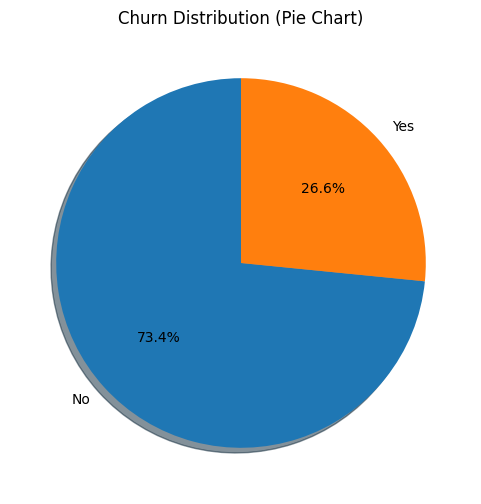

In [15]:
plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

plt.title("Churn Distribution (Pie Chart)")
plt.show()

Supprimer Id

In [16]:
# remove id column
df = df.drop(columns=['customerID'])
# remove missing values
df.dropna(inplace=True)

In [17]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


Vérifier les valeurs uniques

In [18]:
for col in df.columns:
    if df[col].dtype != 'int64' and df[col].dtype != 'float64':
        print(f'{col} : {df[col].unique()}')

gender : ['Female' 'Male']
Partner : ['Yes' 'No']
Dependents : ['No' 'Yes']
PhoneService : ['No' 'Yes']
MultipleLines : ['No phone service' 'No' 'Yes']
InternetService : ['DSL' 'Fiber optic' 'No']
OnlineSecurity : ['No' 'Yes' 'No internet service']
OnlineBackup : ['Yes' 'No' 'No internet service']
DeviceProtection : ['No' 'Yes' 'No internet service']
TechSupport : ['No' 'Yes' 'No internet service']
StreamingTV : ['No' 'Yes' 'No internet service']
StreamingMovies : ['No' 'Yes' 'No internet service']
Contract : ['Month-to-month' 'One year' 'Two year']
PaperlessBilling : ['Yes' 'No']
PaymentMethod : ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn : ['No' 'Yes']


Visualisation

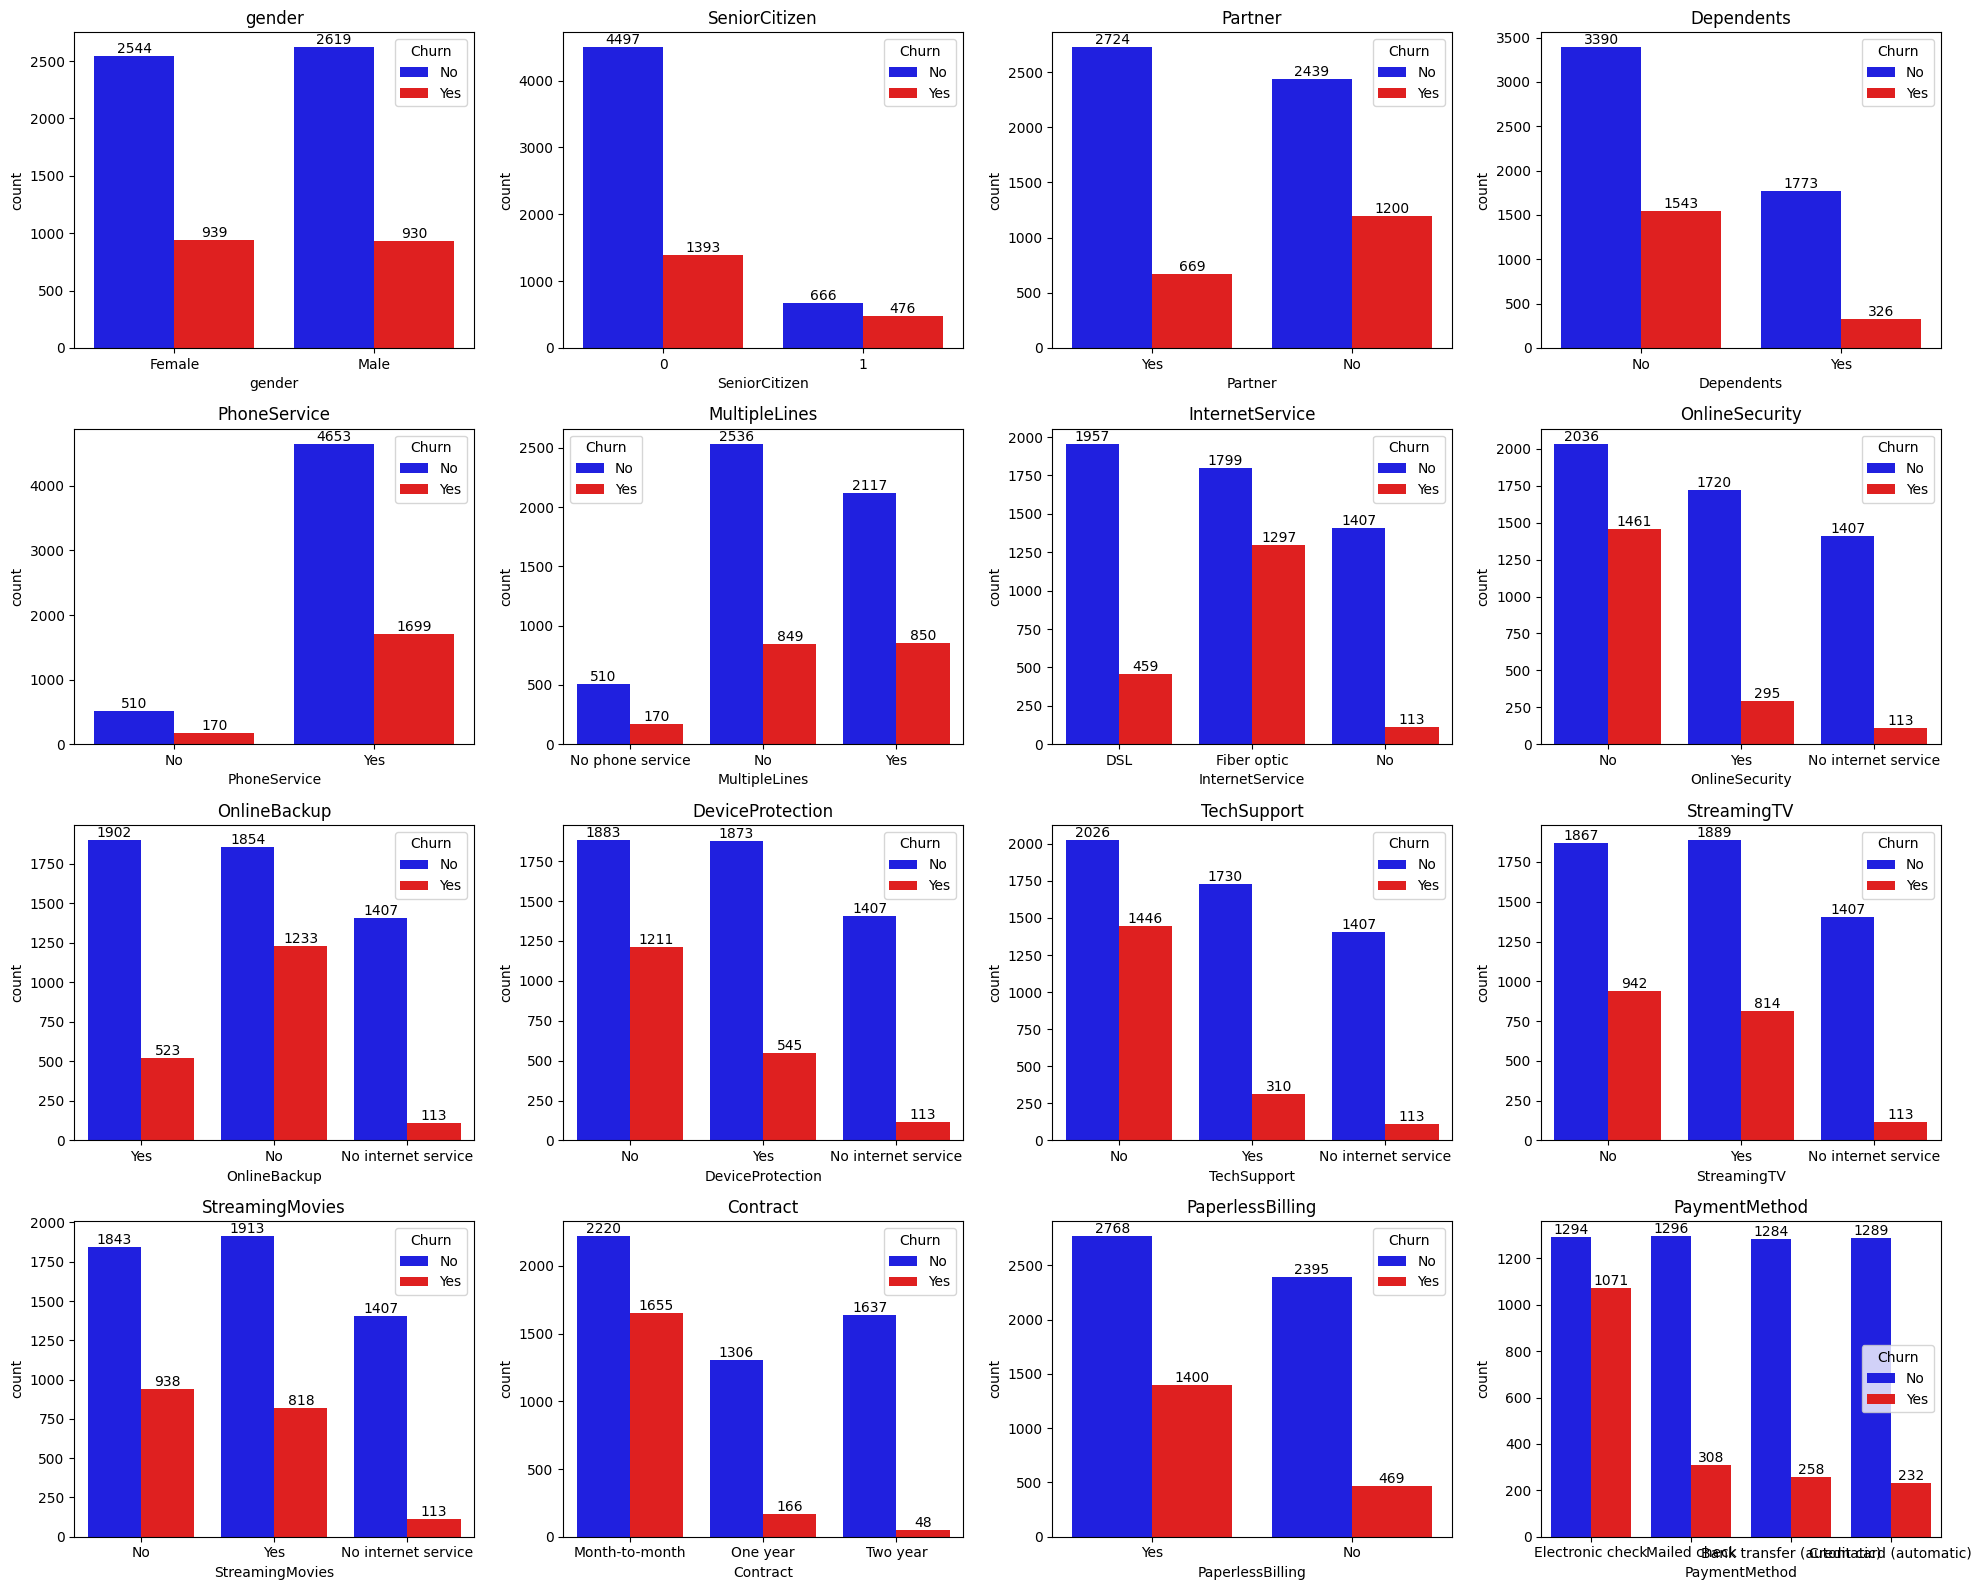

In [19]:
import math

colors = {'Yes': 'red', 'No': 'blue'}
predictors = df.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges', 'tenure']).columns
n_cols = 4
n_rows = math.ceil(len(predictors) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, predictor in enumerate(predictors):
    ax = axes[i]

    sns.countplot(data=df, x=predictor, hue='Churn', palette=colors, ax=ax)
    ax.set_title(predictor)

    for container in ax.containers:
        ax.bar_label(container)

for j in range(len(predictors), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Les fréquences des varaibles

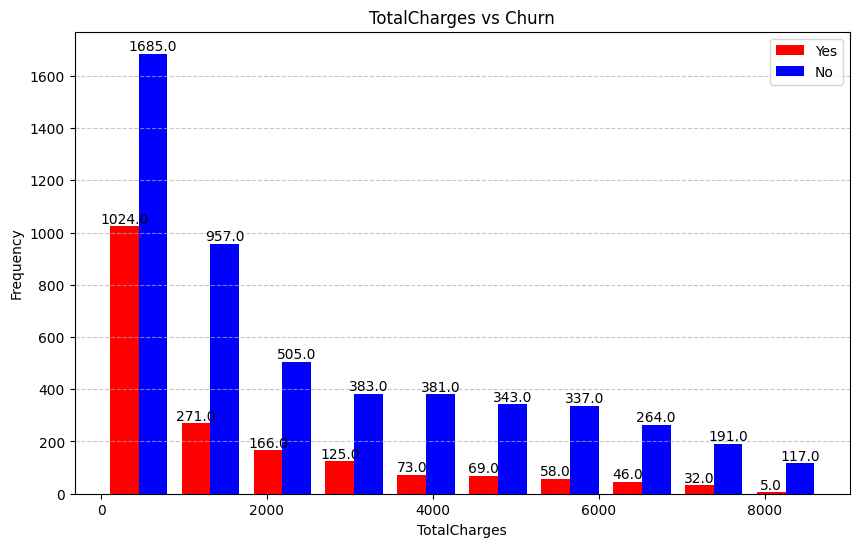

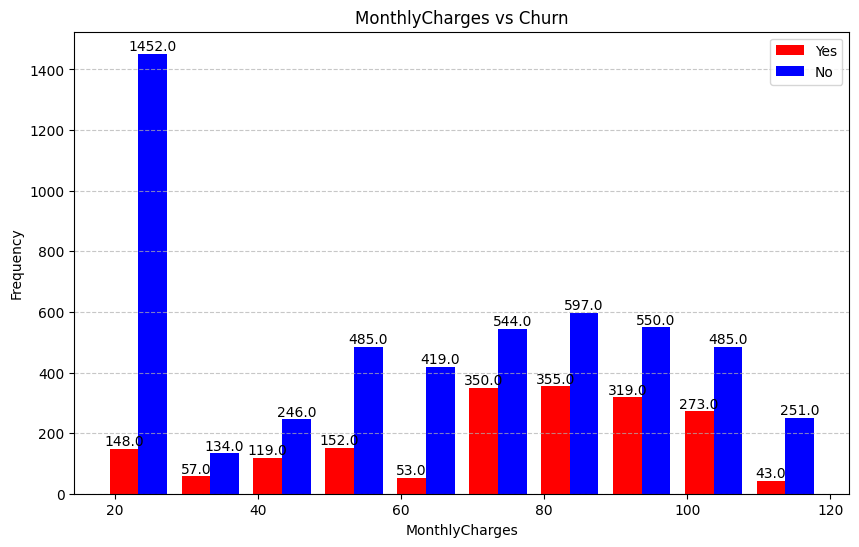

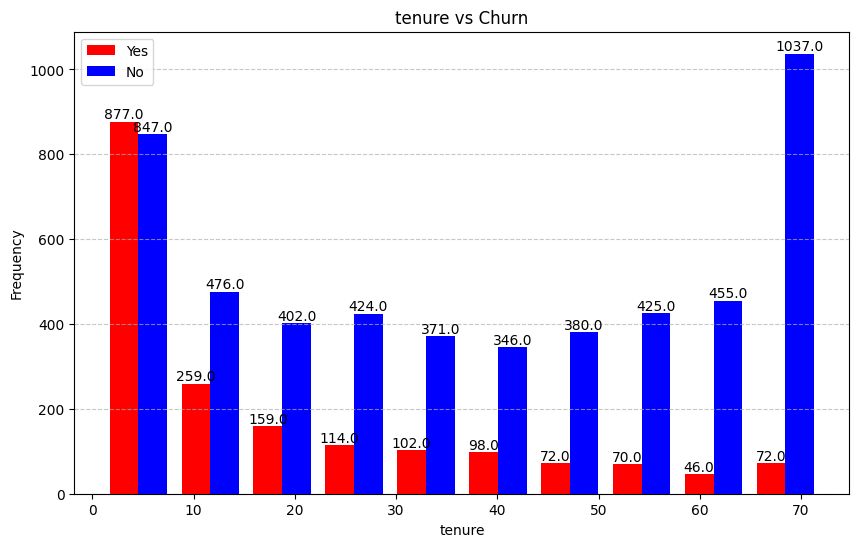

In [20]:
# make plot for tenure
churned = df[df['Churn'] == 'Yes']
not_churned = df[df['Churn'] == 'No']

# col numérique
cols = ['TotalCharges', 'MonthlyCharges', 'tenure']

for col in cols:
  plt.figure(figsize=(10, 6))
  plt.hist([churned[col], not_churned[col]], bins=10,color=['red', 'blue'], label=['Yes', 'No'])
  plt.title(f'{col} vs Churn')
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.legend()
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')
  plt.show()

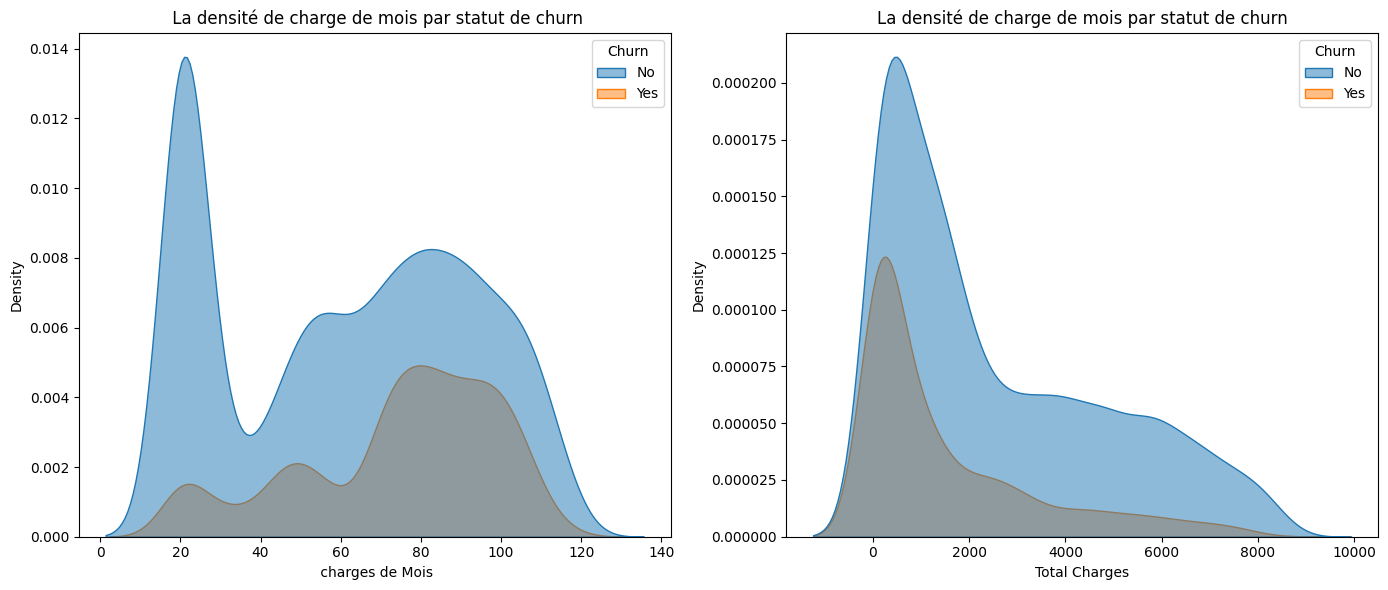

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Monthly Charges
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[0])
axes[0].set_title(' La densité de charge de mois par statut de churn')
axes[0].set_xlabel(' charges de Mois')
axes[0].set_ylabel('Density')

# Plot for Total Charges
sns.kdeplot(data=df, x="TotalCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('La densité de charge de mois par statut de churn')
axes[1].set_xlabel('Total Charges')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

# transformation des variables

In [22]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [77]:
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# Identify categorical columns (excluding target)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

# One-Hot Encode categorical features
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


# Split dataset into X and y

X = df.drop('Churn', axis=1)  # Features
y = df['Churn']               # Target

print("X shape:", X.shape)
print("y shape:", y.shape)
# data into train and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)

X shape: (7032, 32)
y shape: (7032,)


# Entrainement du modèle

In [60]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

In [79]:
# Calcul du déséquilibre pour dire à XGBoost combien pèse un "Churn=1" par rapport à un "Churn=0"
ratio_desequilibre = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Ajout des class_weight='balanced' et scale_pos_weight aux 5 meilleurs modèles
models = [
    ('XG Boost',
     # On ajoute le ratio ici pour booster la détection de la classe 1
     XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=ratio_desequilibre),
     {'model__n_estimators': [50, 100], 'model__learning_rate': [0.01, 0.1]}),

    ('Random Forest',
     RandomForestClassifier(random_state=42, class_weight='balanced'),
     {'model__n_estimators': [50, 100], 'model__max_depth': [None, 5, 10]}),

    ('Logistic Regression',
     LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced'),
     {'model__penalty': ['l1', 'l2'], 'model__C': [0.1, 1.0, 10.0]}),

    ('Gradient Boosting',
     GradientBoostingClassifier(random_state=42),
     {'model__n_estimators': [50, 100], 'model__learning_rate': [0.01, 0.1]}),

    ('Support Vector Machine',
     SVC(random_state=42, class_weight='balanced'),
     {'model__C': [0.1, 1.0], 'model__kernel': ['linear', 'rbf']})
]

best_model = None
best_f1 = 0.0
model_scores = []

print(" Lancement de l'évaluation des 5 meilleurs modèles (Optimisation pour le F1-SCORE)...\n" + "-"*40)

for name, model, param_grid in models:
    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', model)
    ])

    # scoring='f1'
    if param_grid:
        grid_search = GridSearchCV(pipeline, param_grid, cv=2, n_jobs=-1, scoring='f1')
        grid_search.fit(X_train, y_train)
        pipeline = grid_search.best_estimator_
    else:
        pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    model_scores.append({'Model': name, 'Accuracy': accuracy, 'Recall (Churn)': recall, 'F1-Score': f1})

    print(f"Model: {name}")
    print(f"Test Accuracy : {accuracy:.3f}")
    print(f"Test Recall   : {recall:.3f}")
    print(f"Test F1-Score : {f1:.3f} ")
    print("-" * 30)

    # Sélection basée sur le F1-Score
    if f1 > best_f1:
        best_f1 = f1
        best_model = pipeline

scores_df = pd.DataFrame(model_scores).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("\n Classement final des modèles (Basé sur le F1-Score) :")
print(scores_df.to_string())

 Lancement de l'évaluation des 5 meilleurs modèles (Optimisation pour le F1-SCORE)...
----------------------------------------


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:34:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XG Boost
Test Accuracy : 0.739
Test Recall   : 0.783
Test F1-Score : 0.615 
------------------------------
Model: Random Forest
Test Accuracy : 0.731
Test Recall   : 0.810
Test F1-Score : 0.616 
------------------------------
Model: Logistic Regression
Test Accuracy : 0.726
Test Recall   : 0.797
Test F1-Score : 0.608 
------------------------------
Model: Gradient Boosting
Test Accuracy : 0.790
Test Recall   : 0.513
Test F1-Score : 0.565 
------------------------------
Model: Support Vector Machine
Test Accuracy : 0.726
Test Recall   : 0.775
Test F1-Score : 0.600 
------------------------------

 Classement final des modèles (Basé sur le F1-Score) :
                    Model  Accuracy  Recall (Churn)  F1-Score
0           Random Forest  0.731343        0.810160  0.615854
1                XG Boost  0.739161        0.783422  0.614900
2     Logistic Regression  0.726368        0.796791  0.607543
3  Support Vector Machine  0.725657        0.775401  0.600414
4       Gradient Boosting

Evaluation du modèle

[[726 307]
 [ 71 303]]




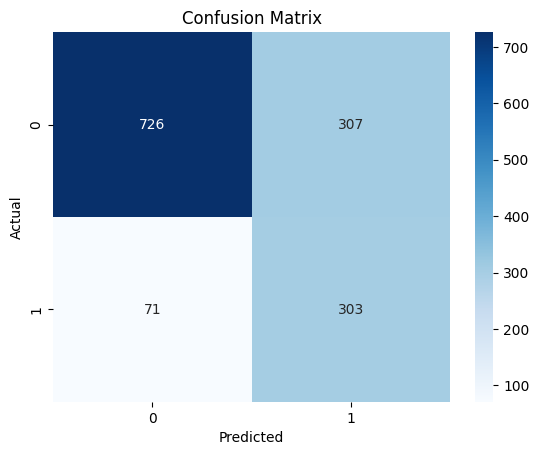

In [80]:
# matrice de confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns

if best_model:
  m = confusion_matrix(y_test, best_model.predict(X_test))
  print(confusion_matrix(y_test, best_model.predict(X_test)))
  print("\n")
  sns.heatmap(m, annot=True, fmt='d', cmap='Blues')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()


In [83]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb

# Création du pipeline spécifique à XGBoost
xgb_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=ratio_desequilibre))
])

# L'espace de recherche (La grille de Fine-Tuning)
# Au lieu de donner 2 ou 3 valeurs fixes, on donne des "plages" de valeurs à explorer
param_distributions = {
    'model__n_estimators': randint(100, 600),          # Nombre d'arbres : on cherche entre 100 et 600
    'model__learning_rate': uniform(0.01, 0.2),        # Vitesse d'apprentissage : n'importe quelle valeur entre 0.01 et 0.21
    'model__max_depth': randint(3, 10),                # Profondeur de l'arbre : entre 3 et 10
    'model__subsample': uniform(0.6, 0.4),             # Pourcentage de lignes utilisées par arbre (entre 60% et 100%)
    'model__colsample_bytree': uniform(0.6, 0.4),      # Pourcentage de colonnes utilisées par arbre (entre 60% et 100%)
    'model__gamma': uniform(0, 0.5)                    # Seuil de régularisation pour éviter le surapprentissage
}

print(" Lancement du Fine-Tuning intensif sur XGBoost...")
print("L'algorithme va tester 30 combinaisons aléatoires complexes avec une validation croisée de 5 plis.\n")

# 3. Configuration de la recherche aléatoire
random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=30,           # Nombre de combinaisons uniques testées
    cv=5,                # Validation croisée robuste (5 plis au lieu de 2)
    scoring='f1',        # On garde le cap : on optimise le compromis F1-Score !
    n_jobs=-1,           # Utilise tous les cœurs de ton processeur
    random_state=42,
    verbose=1            # Affiche la progression
)

# 4. Entraînement
random_search.fit(X_train, y_train)

# 5. Résultats et Prédictions avec le modèle Fine-Tuné
best_xgb_finetuned = random_search.best_estimator_
y_pred_finetuned = best_xgb_finetuned.predict(X_test)

print("\n Fine-Tuning Terminé ! Meilleurs hyperparamètres trouvés :")
for param, value in random_search.best_params_.items():
    print(f" - {param.replace('model__', '')} : {value}")

print("\n Rapport de Performance du Modèle Fine-Tuné :")
print(classification_report(y_test, y_pred_finetuned))

print("\n Matrice de Confusion :")
print(confusion_matrix(y_test, y_pred_finetuned))

 Lancement du Fine-Tuning intensif sur XGBoost...
L'algorithme va tester 30 combinaisons aléatoires complexes avec une validation croisée de 5 plis.

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:49:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Fine-Tuning Terminé ! Meilleurs hyperparamètres trouvés :
 - colsample_bytree : 0.7579526072702278
 - gamma : 0.14674408735901906
 - learning_rate : 0.012815964543016891
 - max_depth : 5
 - n_estimators : 180
 - subsample : 0.88453678109946

 Rapport de Performance du Modèle Fine-Tuné :
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1033
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407


 Matrice de Confusion :
[[732 301]
 [ 71 303]]


Exemples de prédictions

In [84]:
import pandas as pd

# Création de l'échantillon
echantillon_X = X_test.sample(20, random_state=99)
echantillon_y = y_test.loc[echantillon_X.index]

# On récupère les probabilités exactes (colonne 1 = probabilité de Churn)
probabilites = best_xgb_finetuned.predict_proba(echantillon_X)[:, 1]


seuil = 0.70
predictions_personnalisees = (probabilites >= seuil).astype(int)

# 4. Créer un tableau pour comparer la prédiction personnalisée à la réalité
resultats_df = pd.DataFrame({
    'ID_Client (Index)': echantillon_X.index,
    'Risque de Churn (%)': (probabilites * 100).round(1),
    'Prédiction Modèle (>70%)': ['Partira (1)' if p == 1 else 'Restera (0)' for p in predictions_personnalisees],
    'Réalité (Vrai Statut)': ['Parti (1)' if y == 1 else 'Resté (0)' for y in echantillon_y]
})

print(f"Test du modèle XGBoost sur 20 clients (Seuil d'exigence : {seuil*100}%) :\n")
print(resultats_df.to_string(index=False))

Test du modèle XGBoost sur 20 clients (Seuil d'exigence : 70.0%) :

 ID_Client (Index)  Risque de Churn (%) Prédiction Modèle (>70%) Réalité (Vrai Statut)
              1509            70.699997              Partira (1)             Parti (1)
              4882             7.400000              Restera (0)             Resté (0)
              6761            66.599998              Restera (0)             Resté (0)
              4002             7.600000              Restera (0)             Resté (0)
              3629             8.400000              Restera (0)             Resté (0)
              4612             9.500000              Restera (0)             Resté (0)
               676            12.100000              Restera (0)             Resté (0)
              3405            35.299999              Restera (0)             Resté (0)
              4881            44.900002              Restera (0)             Resté (0)
              3007            66.000000              Restera (